In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.figsize'] = (20, 10)

In [2]:
df1 = pd.read_csv('retail_sales_dataset.csv')
df1.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [4]:
df1.shape

(120000, 17)

In [5]:
df1.columns

Index(['transaction_id', 'transaction_date', 'customer_id', 'customer_gender',
       'customer_age_group', 'customer_segment', 'product_id', 'product_name',
       'category', 'brand', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount', 'payment_method', 'sales_channel', 'region'],
      dtype='object')

In [13]:
df1['customer_gender'].unique()

array(['Other', 'Male', 'Female'], dtype=object)

In [14]:
df1['customer_segment'].unique()

array(['Returning', 'New', 'VIP', 'Loyal'], dtype=object)

In [15]:
df1['product_name'].unique()

array(['Dumbbells', 'Running Shoes', 'Sneakers', 'Sunscreen', 'Bread',
       'Rice', 'Board Game', 'Jeans', 'Cookware Set', 'Novel', 'Textbook',
       'Lipstick', 'Bluetooth Speaker', 'Lamp', 'Storage Box', 'Notebook',
       'Building Blocks', 'Perfume', 'Yoga Mat', 'Dress', 'Cookbook',
       'Towel', 'Laptop', 'Coffee', 'Football', 'Puzzle', 'Headphones',
       'Moisturizer', 'Cereal', 'Jacket', 'Smartphone', 'Water Bottle',
       'Children Book', 'Milk', 'T-Shirt', 'Toy Car', 'Smartwatch',
       'Bedsheet', 'Shampoo', 'Doll'], dtype=object)

In [16]:
df1['payment_method'].unique()

array(['Debit Card', 'Credit Card', 'Gift Card', 'Cash', 'PayPal'],
      dtype=object)

In [17]:
df1['sales_channel'].unique()

array(['Online', 'In-Store', 'Mobile App'], dtype=object)

In [18]:
df1['region'].unique()

array(['North', 'South', 'Central', 'East', 'West'], dtype=object)

In [19]:
df1['brand'].unique()

array(['Brand 1', 'Brand 3', 'Brand 2'], dtype=object)

In [7]:
df1.dtypes

transaction_id         object
transaction_date       object
customer_id            object
customer_gender        object
customer_age_group     object
customer_segment       object
product_id             object
product_name           object
category               object
brand                  object
quantity                int64
unit_price            float64
discount_pct            int64
sales_amount          float64
payment_method         object
sales_channel          object
region                 object
dtype: object

In [8]:
df1.describe()

,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1.662908,240.621785,5.496500,377.975454
std,1.014291,146.457057,8.193257,356.893357
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,30.000000,2467.550000


In [9]:
df2 = df1.drop(['transaction_id', 'customer_id', 'product_id'], axis=1)
df2.shape

(120000, 14)

Xử lý các giá trị NA

In [10]:
df2.isnull().sum()

transaction_date      0
customer_gender       0
customer_age_group    0
customer_segment      0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

Xử lý outliers

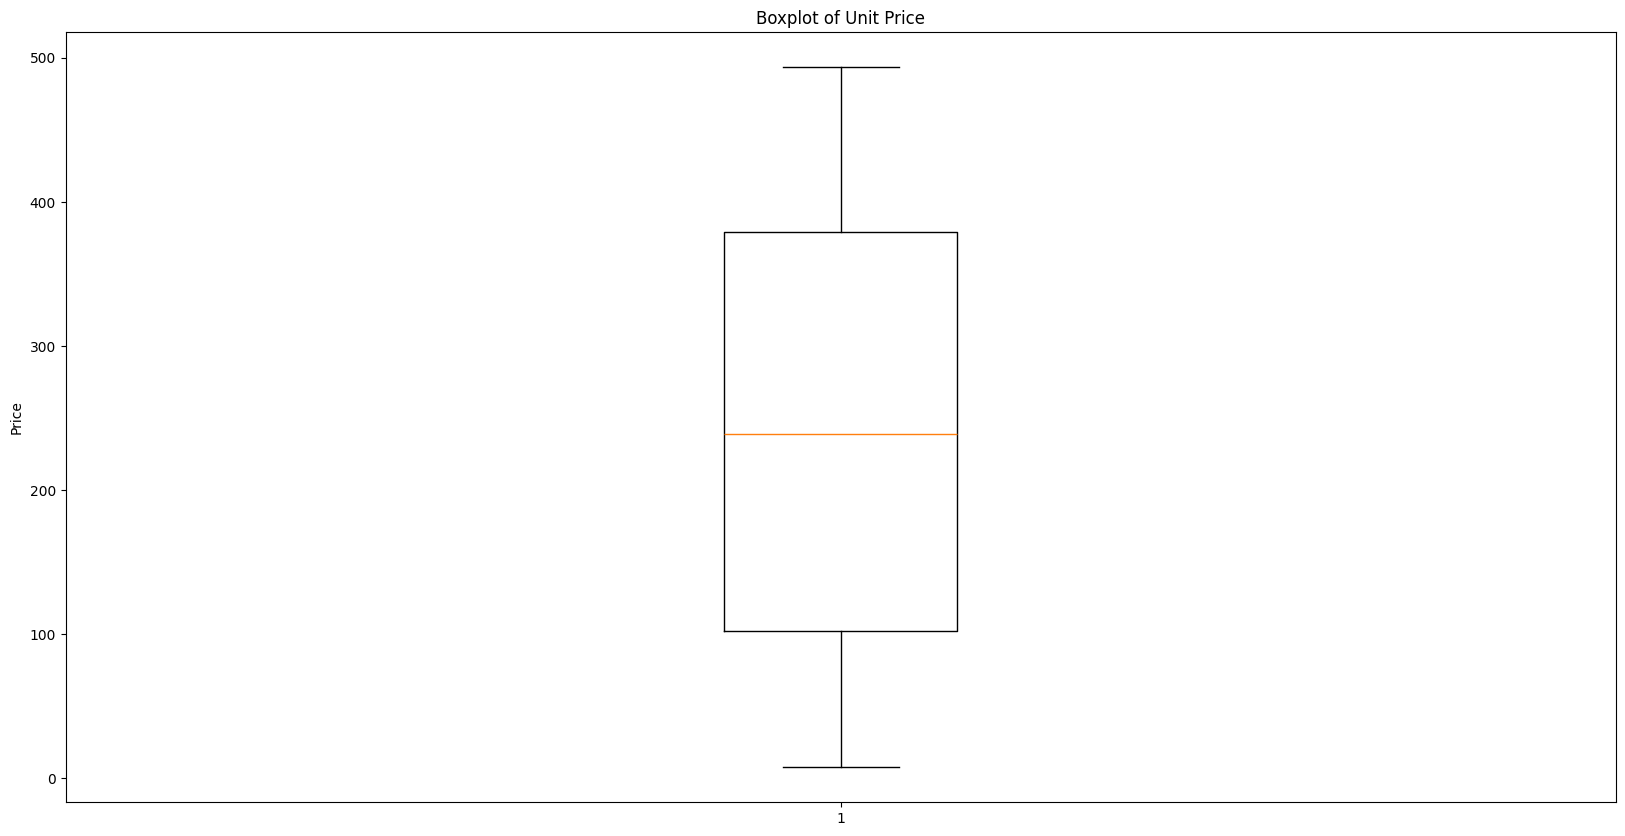

In [25]:
plt.boxplot(df2['unit_price'])
plt.title("Boxplot of Unit Price")
plt.ylabel("Price")
plt.show()

In [27]:
Q1 = df2.unit_price.quantile(0.25)
Q3 = df2.unit_price.quantile(0.75)
Q1, Q3

(np.float64(102.01), np.float64(379.0))

In [28]:
IQR = Q3 - Q1
IQR

np.float64(276.99)

In [29]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
lower_limit, upper_limit

(np.float64(-313.475), np.float64(794.485))

In [30]:
df2[(df2.unit_price < lower_limit) | (df2.unit_price > upper_limit)]

,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region


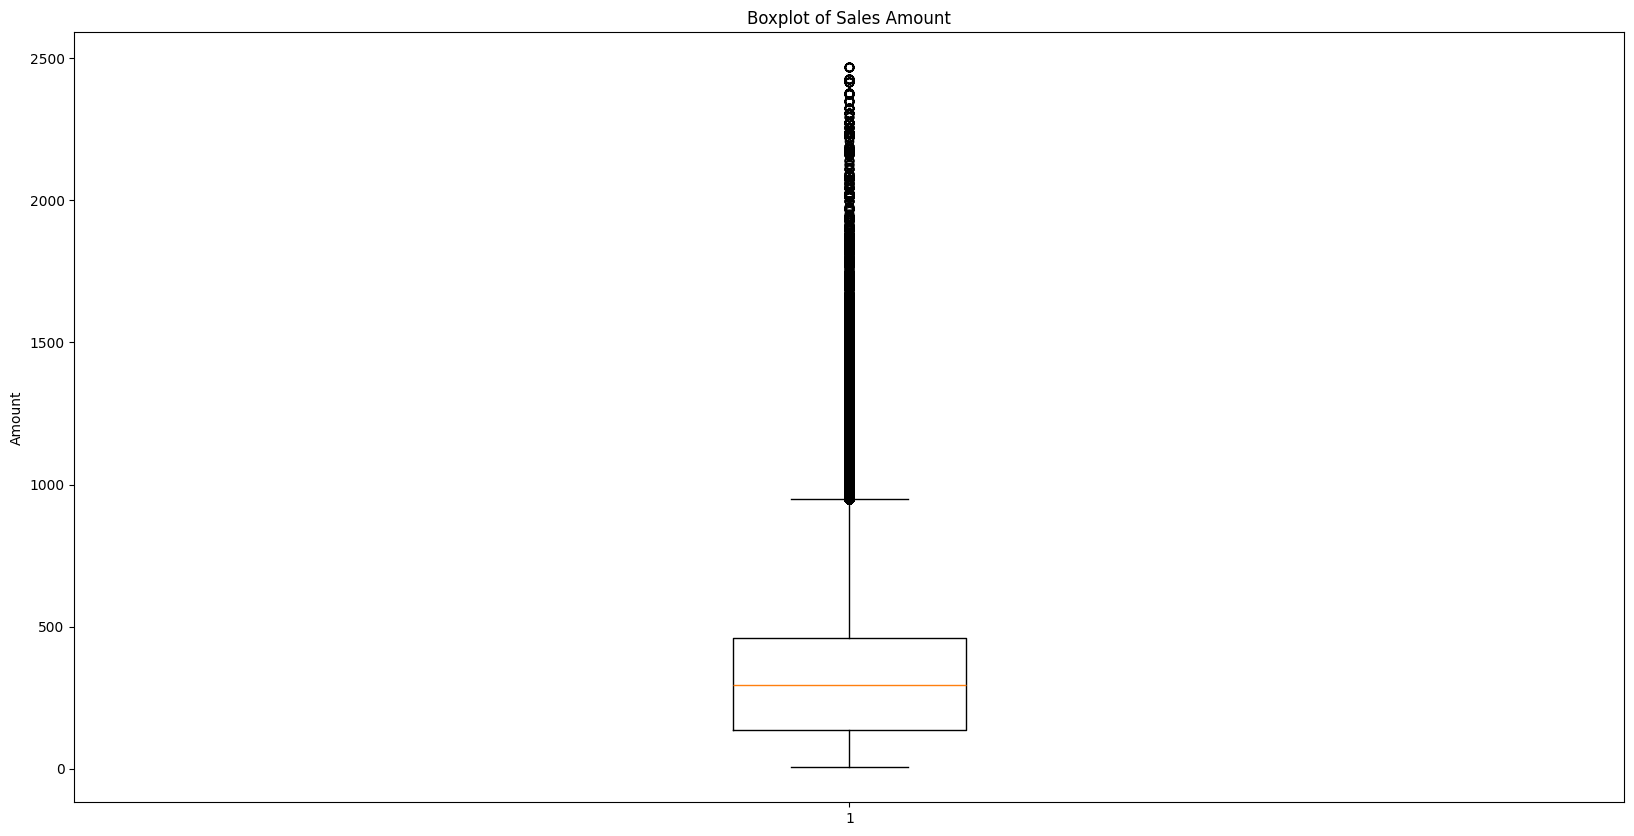

In [31]:
#sales_amount
plt.boxplot(df2['sales_amount'])
plt.title("Boxplot of Sales Amount")
plt.ylabel("Amount")
plt.show()

In [32]:
Q1 = df2['sales_amount'].quantile(0.25)
Q3 = df2['sales_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df2[(df2.sales_amount < lower_limit) | (df2.sales_amount > upper_limit)]

,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
10,2024-02-27,Male,35-44,VIP,Novel,Books,Brand 3,4,379.00,0,1516.00,Cash,Online,South
21,2025-06-24,Female,25-34,Returning,Bread,Groceries,Brand 1,2,474.70,0,949.40,Cash,In-Store,East
29,2025-04-18,Male,45-54,New,Bread,Groceries,Brand 3,4,405.16,0,1620.64,Credit Card,Mobile App,Central
36,2025-08-31,Other,18-24,VIP,Towel,Home,Brand 3,3,354.89,5,1011.44,Gift Card,Mobile App,Central
46,2024-02-06,Other,55+,Returning,Storage Box,Home,Brand 1,2,493.51,0,987.02,PayPal,Online,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119967,2025-01-15,Male,25-34,New,Smartwatch,Electronics,Brand 1,4,355.50,0,1422.00,Credit Card,Online,South
119978,2025-11-29,Female,18-24,Loyal,Smartphone,Electronics,Brand 3,4,367.34,0,1469.36,Credit Card,Online,East
119981,2024-02-29,Female,25-34,Loyal,Towel,Home,Brand 2,4,408.65,5,1552.87,Credit Card,Online,North
119983,2025-06-04,Other,55+,Returning,Yoga Mat,Sports,Brand 2,3,386.78,0,1160.34,PayPal,Mobile App,West


In [45]:
#Log transformation cho sales_amount
df2['sales_amount_log'] = np.log1p(df2['sales_amount'])

In [47]:
df2.head()

,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region,sales_amount_log
0,2024-04-24,Other,35-44,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North,6.219894
1,2025-07-12,Other,45-54,New,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South,5.905798
2,2025-06-01,Male,55+,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South,3.366951
3,2025-08-26,Male,25-34,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South,5.161466
4,2024-12-10,Male,45-54,New,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central,5.562795


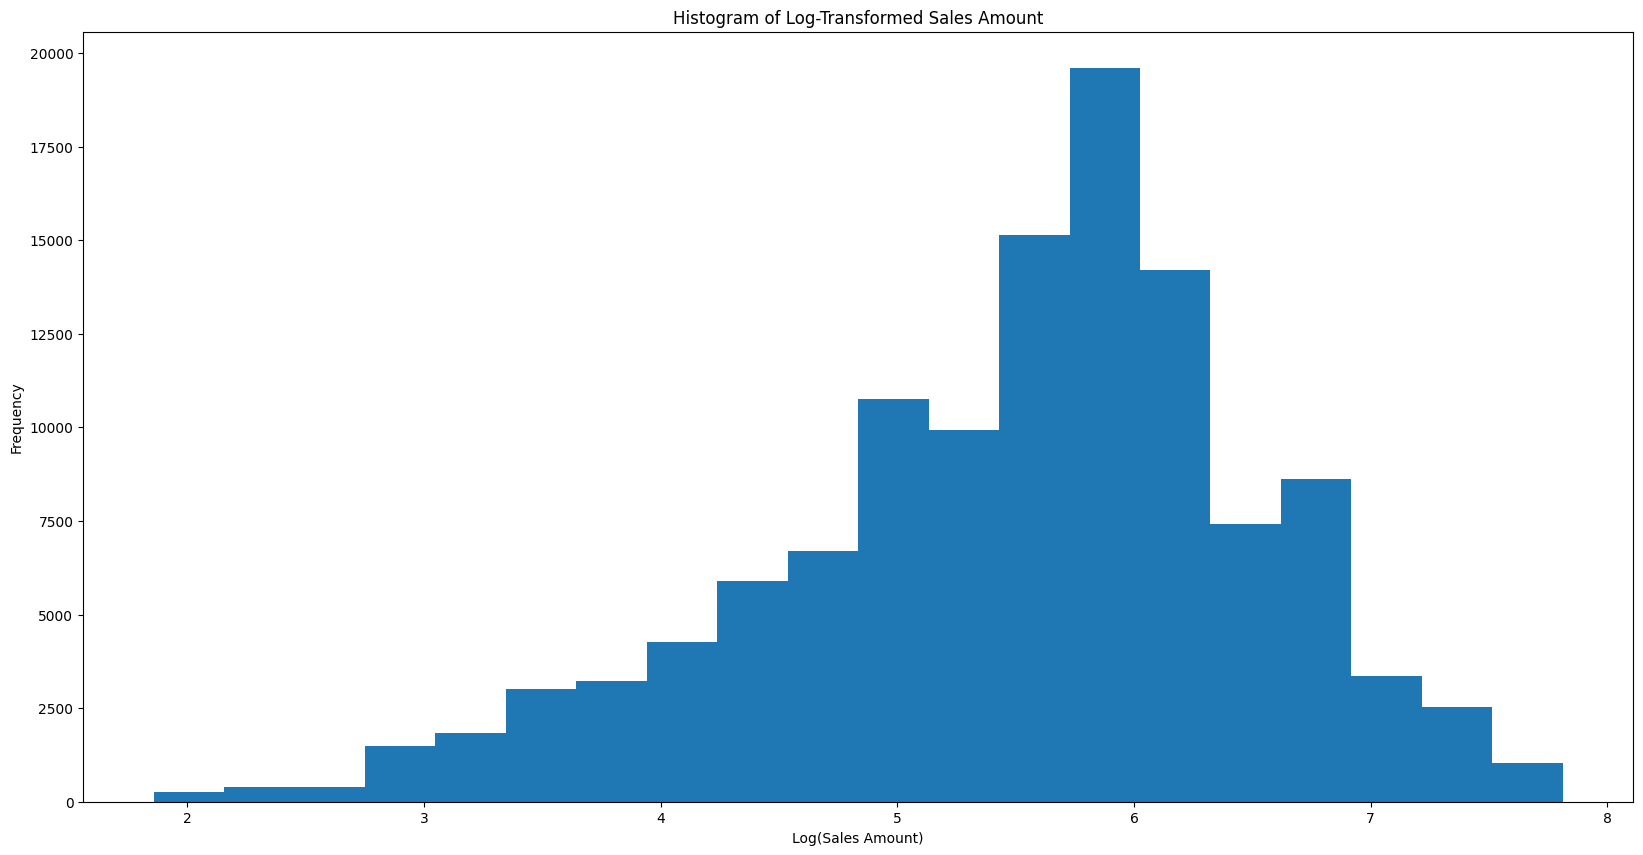

In [50]:
plt.hist(df2['sales_amount_log'], bins=20)
plt.title("Histogram of Log-Transformed Sales Amount")
plt.xlabel("Log(Sales Amount)")
plt.ylabel("Frequency")
plt.show()

In [51]:
df3 = df2.drop(['sales_amount'], axis=1)
df3.head()

,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,payment_method,sales_channel,region,sales_amount_log
0,2024-04-24,Other,35-44,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,Debit Card,Online,North,6.219894
1,2025-07-12,Other,45-54,New,Running Shoes,Sports,Brand 3,1,366.16,0,Credit Card,Online,South,5.905798
2,2025-06-01,Male,55+,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,Gift Card,In-Store,South,3.366951
3,2025-08-26,Male,25-34,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,Cash,In-Store,South,5.161466
4,2024-12-10,Male,45-54,New,Sneakers,Clothing,Brand 1,1,259.55,0,Cash,In-Store,Central,5.562795


Xử lý dữ liệu phân loại và Mất cân bằng

In [54]:
categorical_cols = df3.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Value counts for {col}:")
    print(df3[col].value_counts(normalize=True) * 100)
    print("\n")

Value counts for transaction_date:
transaction_date
2025-07-06    0.166667
2024-06-30    0.166667
2024-03-30    0.166667
2024-02-07    0.165833
2025-04-17    0.165833
                ...   
2024-07-31    0.111667
2025-05-20    0.110833
2025-05-24    0.108333
2025-08-25    0.106667
2024-10-08    0.102500
Name: proportion, Length: 730, dtype: float64


Value counts for customer_gender:
customer_gender
Female    33.556667
Other     33.255000
Male      33.188333
Name: proportion, dtype: float64


Value counts for customer_age_group:
customer_age_group
35-44    20.163333
55+      20.065000
18-24    19.950833
45-54    19.932500
25-34    19.888333
Name: proportion, dtype: float64


Value counts for customer_segment:
customer_segment
VIP          25.095833
New          25.016667
Loyal        25.011667
Returning    24.875833
Name: proportion, dtype: float64


Value counts for product_name:
product_name
Dumbbells            2.590000
T-Shirt              2.567500
Yoga Mat             2.553333
Sha

In [ ]:
# Mã hóa dữ liệu
df4 = df3.copy()

In [62]:
# Ordinary Encoding - customer_age_group
age_mapping = {
    '18-24': 0,
    '25-34': 1,
    '35-44': 2,
    '45-54': 3,
    '55+': 4
}
df4['customer_age_group_encoded'] = df4['customer_age_group'].map(age_mapping)

In [65]:
print(df4['customer_age_group_encoded'].value_counts())
print("Số lượng dòng bị lỗi map:", df4['customer_age_group_encoded'].isna().sum())

customer_age_group_encoded
2    24196
4    24078
0    23941
3    23919
1    23866
Name: count, dtype: int64
Số lượng dòng bị lỗi map: 0


In [66]:
df5 = df4.drop(['customer_age_group'], axis=1)
df5.head()

,transaction_date,customer_gender,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,payment_method,sales_channel,region,sales_amount_log,customer_age_group_encoded
0,2024-04-24,Other,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,Debit Card,Online,North,6.219894,2
1,2025-07-12,Other,New,Running Shoes,Sports,Brand 3,1,366.16,0,Credit Card,Online,South,5.905798,3
2,2025-06-01,Male,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,Gift Card,In-Store,South,3.366951,4
3,2025-08-26,Male,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,Cash,In-Store,South,5.161466,1
4,2024-12-10,Male,New,Sneakers,Clothing,Brand 1,1,259.55,0,Cash,In-Store,Central,5.562795,3


Creation feature và Mã hóa

In [92]:
df5['transaction_date'] = pd.to_datetime(df5['transaction_date'])
df6 = df5.sort_values(['product_name', 'transaction_date'], ascending=[True, True]).reset_index(drop=True)

rolling_res = (df6.groupby('product_name')
                           .rolling('30D', on='transaction_date', closed='left')['quantity']
                           .mean())

df6['qty_roll_mean_30d'] = rolling_res.values
df6['qty_roll_mean_30d'] = df6['qty_roll_mean_30d'].fillna(0)

print(df6[['product_name', 'transaction_date', 'quantity', 'qty_roll_mean_30d']].head(10))

  product_name transaction_date  quantity  qty_roll_mean_30d
0     Bedsheet       2024-01-01         1           0.000000
1     Bedsheet       2024-01-01         3           0.000000
2     Bedsheet       2024-01-01         2           0.000000
3     Bedsheet       2024-01-01         1           0.000000
4     Bedsheet       2024-01-01         1           0.000000
5     Bedsheet       2024-01-01         1           0.000000
6     Bedsheet       2024-01-01         2           0.000000
7     Bedsheet       2024-01-02         1           1.571429
8     Bedsheet       2024-01-02         2           1.571429
9     Bedsheet       2024-01-02         2           1.571429


In [ ]:
ohe_columns = [
    'customer_gender', 'customer_segment', 'product_name', 
    'category', 'brand', 'payment_method', 'sales_channel', 'region'
]
df7_encoded = pd.get_dummies(df6, columns=ohe_columns, dtype=int)
df7_encoded.head()

,transaction_date,quantity,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,qty_roll_mean_30d,customer_gender_Female,customer_gender_Male,customer_gender_Other,...,payment_method_Gift Card,payment_method_PayPal,sales_channel_In-Store,sales_channel_Mobile App,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West
0,2024-01-01,1,139.32,0,4.943926,1,0.0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
1,2024-01-01,3,197.40,0,6.385532,1,0.0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
2,2024-01-01,2,415.23,10,6.617951,2,0.0,1,0,0,...,0,0,1,0,0,1,0,0,0,0
3,2024-01-01,1,415.23,0,6.031238,2,0.0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
4,2024-01-01,1,415.23,5,5.980075,3,0.0,1,0,0,...,0,0,1,0,0,0,0,0,1,0


In [99]:
df7_encoded.shape

(120000, 78)

In [100]:
df7_encoded.columns

Index(['transaction_date', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount_log', 'customer_age_group_encoded', 'qty_roll_mean_30d',
       'customer_gender_Female', 'customer_gender_Male',
       'customer_gender_Other', 'customer_segment_Loyal',
       'customer_segment_New', 'customer_segment_Returning',
       'customer_segment_VIP', 'product_name_Bedsheet',
       'product_name_Bluetooth Speaker', 'product_name_Board Game',
       'product_name_Bread', 'product_name_Building Blocks',
       'product_name_Cereal', 'product_name_Children Book',
       'product_name_Coffee', 'product_name_Cookbook',
       'product_name_Cookware Set', 'product_name_Doll', 'product_name_Dress',
       'product_name_Dumbbells', 'product_name_Football',
       'product_name_Headphones', 'product_name_Jacket', 'product_name_Jeans',
       'product_name_Lamp', 'product_name_Laptop', 'product_name_Lipstick',
       'product_name_Milk', 'product_name_Moisturizer',
       'product_name_Notebook

In [101]:
df7_encoded['transaction_year'] = df7_encoded['transaction_date'].dt.year
df7_encoded['transaction_month'] = df7_encoded['transaction_date'].dt.month
df7_encoded['transaction_day'] = df7_encoded['transaction_date'].dt.day
df7_encoded['transaction_dayofweek'] = df7_encoded['transaction_date'].dt.dayofweek

In [102]:
df7_encoded.head()

,transaction_date,quantity,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,qty_roll_mean_30d,customer_gender_Female,customer_gender_Male,customer_gender_Other,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,2024-01-01,1,139.32,0,4.943926,1,0.0,0,1,0,...,0,0,0,0,0,1,2024,1,1,0
1,2024-01-01,3,197.40,0,6.385532,1,0.0,0,0,1,...,1,0,0,1,0,0,2024,1,1,0
2,2024-01-01,2,415.23,10,6.617951,2,0.0,1,0,0,...,0,1,0,0,0,0,2024,1,1,0
3,2024-01-01,1,415.23,0,6.031238,2,0.0,0,0,1,...,0,0,0,1,0,0,2024,1,1,0
4,2024-01-01,1,415.23,5,5.980075,3,0.0,1,0,0,...,0,0,0,0,1,0,2024,1,1,0


In [103]:
df8 = df7_encoded.drop(['transaction_date', 'quantity'], axis=1)

In [104]:
df8.head()

,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,qty_roll_mean_30d,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,139.32,0,4.943926,1,0.0,0,1,0,0,0,...,0,0,0,0,0,1,2024,1,1,0
1,197.40,0,6.385532,1,0.0,0,0,1,0,0,...,1,0,0,1,0,0,2024,1,1,0
2,415.23,10,6.617951,2,0.0,1,0,0,1,0,...,0,1,0,0,0,0,2024,1,1,0
3,415.23,0,6.031238,2,0.0,0,0,1,0,0,...,0,0,0,1,0,0,2024,1,1,0
4,415.23,5,5.980075,3,0.0,1,0,0,0,0,...,0,0,0,0,1,0,2024,1,1,0


Chuẩn hóa thang đo

In [105]:
df9 = df8.copy()

In [108]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['unit_price', 'sales_amount_log', 'qty_roll_mean_30d']
df9[numeric_cols] = scaler.fit_transform(df9[numeric_cols])
df9.head()

,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,qty_roll_mean_30d,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,-0.691685,0,-0.541627,1,-14.478986,0,1,0,0,0,...,0,0,0,0,0,1,2024,1,1,0
1,-0.295117,0,0.860409,1,-14.478986,0,0,1,0,0,...,1,0,0,1,0,0,2024,1,1,0
2,1.192219,10,1.086448,2,-14.478986,1,0,0,1,0,...,0,1,0,0,0,0,2024,1,1,0
3,1.192219,0,0.515840,2,-14.478986,0,0,1,0,0,...,0,0,0,1,0,0,2024,1,1,0
4,1.192219,5,0.466081,3,-14.478986,1,0,0,0,0,...,0,0,0,0,1,0,2024,1,1,0


In [110]:
df9[numeric_cols].describe().round(2)

,unit_price,sales_amount_log,qty_roll_mean_30d
count,120000.00,120000.00,120000.00
mean,-0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.59,-3.54,-14.48
25%,-0.95,-0.56,-0.55
50%,-0.01,0.19,-0.00
75%,0.94,0.62,0.55
max,1.73,2.25,7.31


Selection Feature

<Axes: >

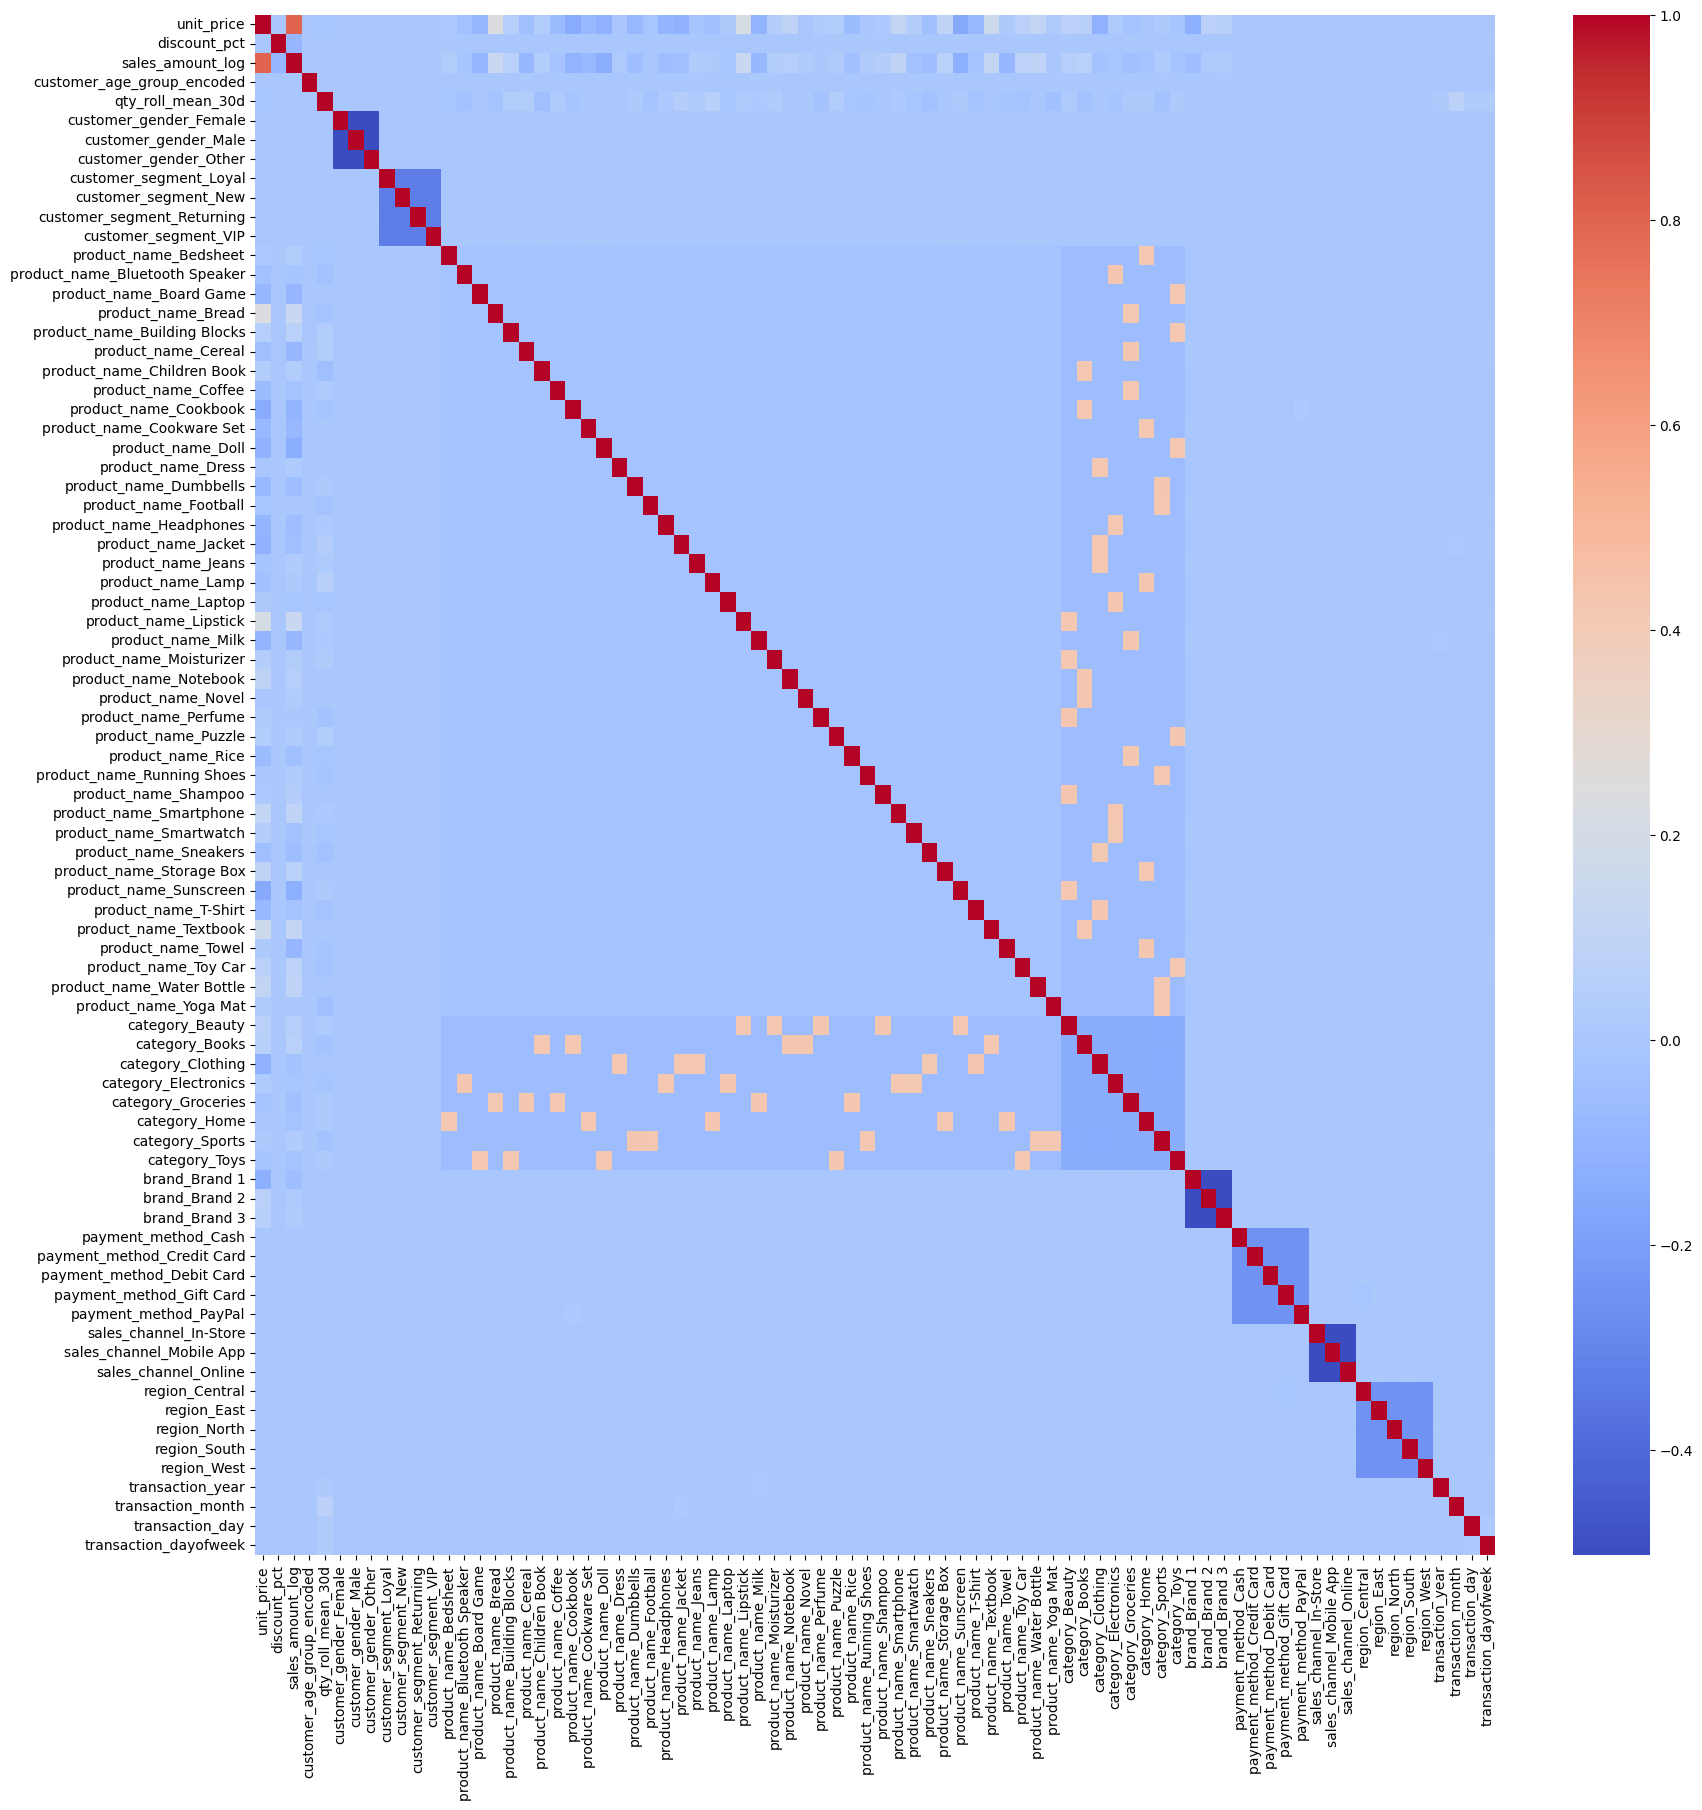

In [112]:
# Correlation Matrix with Heatmap
import seaborn as sns
X = df9.iloc[:, df9.columns != 'sales_amount_log']
Y = df9['sales_amount_log']
corrmat = df9.corr()
top_corr_feature = corrmat.index
plt.figure(figsize=(20, 20))
sns.heatmap(corrmat, annot=False, cmap='coolwarm')

Tách dữ liệu

In [113]:
from sklearn.model_selection import train_test_split

# random_state=42 giúp cố định kết quả xáo trộn để những lần chạy sau luôn ra cùng một đáp án
train_data_rand, test_data_rand = train_test_split(df9, test_size=0.2, random_state=42)

train_data_rand.to_csv('train_data_random_80.csv', index=False)
test_data_rand.to_csv('test_data_random_20.csv', index=False)

print("Data split completed.")

Data split completed.
